Загрузка данных...
Разделение данных...
Коэффициент дисбаланса (scale_pos_weight): 11.39
Начинаю обучение XGBoost...
[0]	validation_0-auc:0.71943
[100]	validation_0-auc:0.75707
[200]	validation_0-auc:0.76384
[300]	validation_0-auc:0.76692
[400]	validation_0-auc:0.76860
[500]	validation_0-auc:0.76911
[600]	validation_0-auc:0.76939
[628]	validation_0-auc:0.76954

Оценка модели...
🚀 ROC AUC Score: 0.7695
Модель сохранена в: ../models\xgboost_credit.json

Генерация SHAP-значений (это может занять время)...
График SHAP сохранен как shap_summary.png


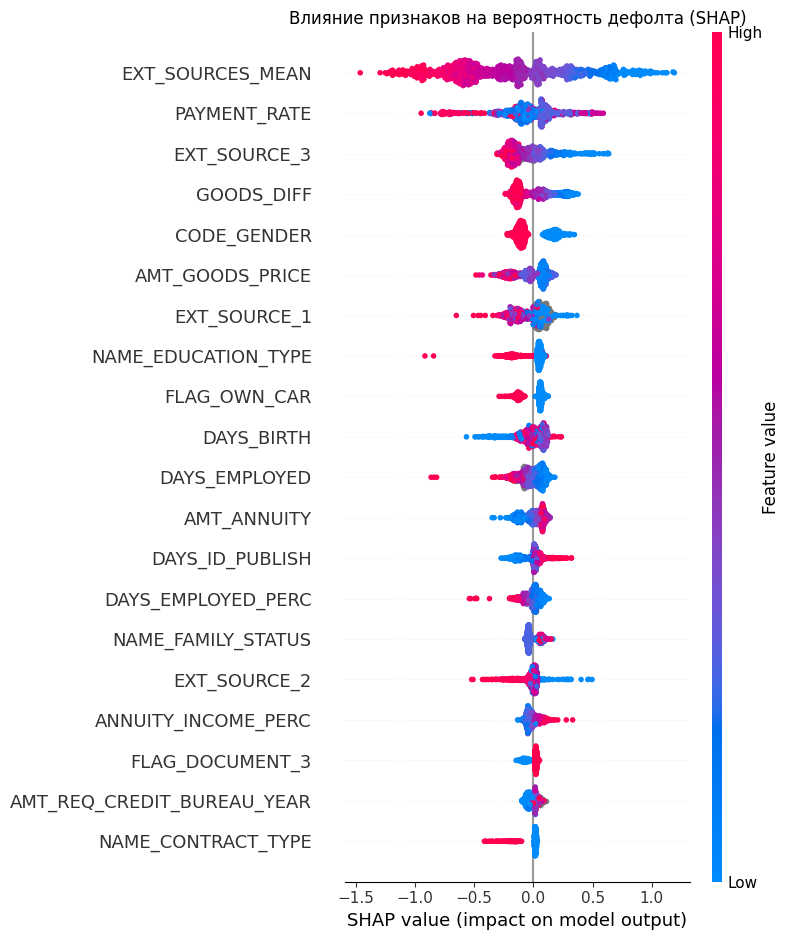

<Figure size 1000x800 with 0 Axes>

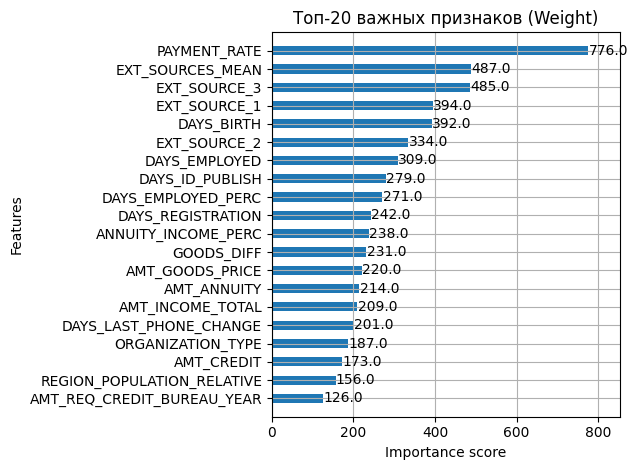

In [1]:
import pandas as pd
import xgboost as xgb
import shap
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, classification_report
import joblib 
import os

# Настройки
INPUT_FILE = '../data/processed/train_final.csv'
MODEL_DIR = '../models'
MODEL_PATH = os.path.join(MODEL_DIR, 'xgboost_credit.json')

def train():
    # 1. Загрузка
    print("Загрузка данных...")
    df = pd.read_csv(INPUT_FILE)
    
    # Удаляем идентификатор (он не нужен для обучения) и целевую переменную
    X = df.drop(['TARGET', 'SK_ID_CURR'], axis=1)
    y = df['TARGET']
    
    # 2. Разделение на train/test (80% на обучение, 20% на проверку)
    # stratify=y сохраняет пропорцию дефолтов (8%) в обоих кусках
    print("Разделение данных...")
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )
    
    # 3. Расчет веса классов (чтобы модель видела "единички")
    # scale_pos_weight = (количество нулей) / (количество единиц)
    ratio = float(np.sum(y == 0)) / np.sum(y == 1)
    print(f"Коэффициент дисбаланса (scale_pos_weight): {ratio:.2f}")
    
    # 4. Инициализация модели
    model = xgb.XGBClassifier(
        n_estimators=1000,       # Максимум деревьев (остановится раньше)
        learning_rate=0.05,      # Медленное, но точное обучение
        max_depth=4,             # Неглубокие деревья (меньше переобучения)
        scale_pos_weight=ratio,  # Важно для дисбаланса!
        subsample=0.8,           # Использовать 80% строк для каждого дерева
        colsample_bytree=0.8,    # Использовать 80% колонок для каждого дерева
        eval_metric='auc',       # Метрика оптимизации
        early_stopping_rounds=50,# Стоп, если не растет 50 итераций
        n_jobs=-1,               # Все ядра процессора
        random_state=42
    )
    
    # 5. Обучение
    print("Начинаю обучение XGBoost...")
    model.fit(
        X_train, y_train,
        eval_set=[(X_test, y_test)],
        verbose=100  # Выводить результат каждые 100 шагов
    )
    
    # 6. Оценка
    print("\nОценка модели...")
    preds_proba = model.predict_proba(X_test)[:, 1]
    auc = roc_auc_score(y_test, preds_proba)
    print(f"🚀 ROC AUC Score: {auc:.4f}")
    
    # 7. Сохранение
    os.makedirs(MODEL_DIR, exist_ok=True)
    model.save_model(MODEL_PATH)
    print(f"Модель сохранена в: {MODEL_PATH}")
    
    # ==========================================
    # БЛОК ДЛЯ ДИПЛОМА (SHAP)
    # ==========================================
    print("\nГенерация SHAP-значений (это может занять время)...")
    
    # Используем TreeExplainer (он быстрый для XGBoost)
    explainer = shap.TreeExplainer(model)
    # Берем небольшую выборку для скорости (например, 1000 строк из теста)
    shap_values = explainer.shap_values(X_test.iloc[:1000])
    
    # График Summary Plot
    plt.figure(figsize=(12, 10))
    shap.summary_plot(shap_values, X_test.iloc[:1000], show=False)
    plt.title("Влияние признаков на вероятность дефолта (SHAP)")
    plt.tight_layout()
    plt.savefig(os.path.join(MODEL_DIR, 'shap_summary.png'))
    print("График SHAP сохранен как shap_summary.png")

    # Важность признаков (стандартная)
    plt.figure(figsize=(10, 8))
    xgb.plot_importance(model, max_num_features=20, height=0.5)
    plt.title("Топ-20 важных признаков (Weight)")
    plt.tight_layout()
    plt.savefig(os.path.join(MODEL_DIR, 'feature_importance.png'))

import numpy as np # Забыл добавить в начале, нужен для ratio

if __name__ == "__main__":
    train()

In [3]:
# Сохраняем модель в формате JSON (лучший формат для XGBoost)
model.save_model('../models/xgb_model_v1.json')
print("Модель сохранена в models/xgb_model_v1.json")

Модель сохранена в models/xgb_model_v1.json


In [2]:
!pip install xgboost --upgrade

INFO: pip is looking at multiple versions of xgboost to determine which version is compatible with other requirements. This could take a while.
  Using cached xgboost-3.1.2-py3-none-win_amd64.whl.metadata (2.1 kB)
  Using cached xgboost-3.1.1-py3-none-win_amd64.whl.metadata (2.1 kB)
INFO: pip is still looking at multiple versions of xgboost to determine which version is compatible with other requirements. This could take a while.
INFO: This is taking longer than usual. You might need to provide the dependency resolver with stricter constraints to reduce runtime. See https://pip.pypa.io/warnings/backtracking for guidance. If you want to abort this run, press Ctrl + C.
     ---------------------------------------- 0.0/574.2 kB ? eta -:--:--
     ---------------------------------------- 0.0/574.2 kB ? eta -:--:--
     ------------------ --------------------- 262.1/574.2 kB ? eta -:--:--
     ------------------ --------------------- 262.1/574.2 kB ? eta -:--:--
     -----------------------

  error: subprocess-exited-with-error
  
  × Preparing metadata (pyproject.toml) did not run successfully.
  │ exit code: 1
  ╰─> [30 lines of output]
      Windows users please use github installation.
      C:\Users\РђРґРјРёРЅ\AppData\Local\Temp\pip-build-env-vr61_4zo\overlay\Lib\site-packages\setuptools\build_meta.py:520: SetuptoolsDeprecationWarning: Running `setup.py` directly as CLI tool is deprecated.
      !!
      
              ********************************************************************************
              Please avoid using `sys.exit(0)` or similar statements that don't fit in the paradigm of a configuration file.
      
              See https://blog.ganssle.io/articles/2021/10/setup-py-deprecated.html for details.
              ********************************************************************************
      
      !!
        super().run_setup(setup_script=setup_script)
      Traceback (most recent call last):
        File "c:\Users\РђРґРјРёРЅ\Desktop\X

c:\Users\Админ\Desktop\XG\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


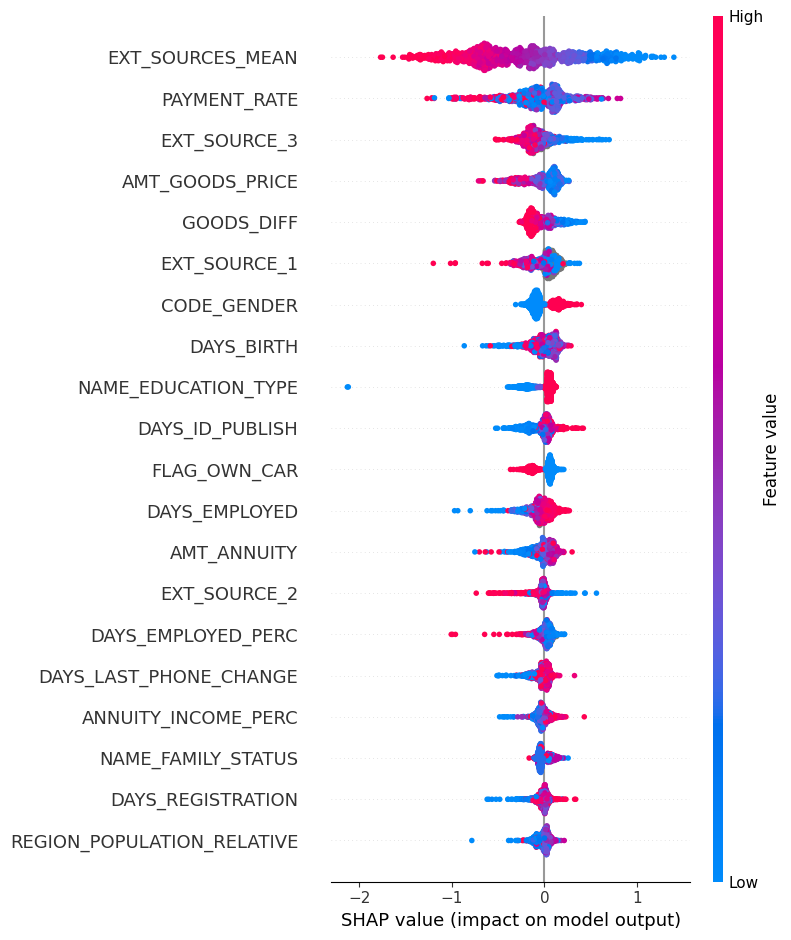

In [4]:
import shap

# Используем небольшую выборку для скорости (SHAP требует ресурсов)
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test.iloc[:1000])

# Визуализация топ-факторов
shap.summary_plot(shap_values, X_test.iloc[:1000])

In [5]:
import joblib
import json

# Получаем список всех столбцов, на которых училась модель
model_columns = list(X.columns)

# Вариант 1: Сохраняем как JSON (удобно для чтения человеком)
with open('../models/model_columns.json', 'w') as f:
    json.dump(model_columns, f)

# Вариант 2: Сохраняем через joblib (удобно для Python)
joblib.dump(model_columns, '../models/model_columns.pkl')

print(f"Список из {len(model_columns)} столбцов успешно сохранен!")

Список из 109 столбцов успешно сохранен!


In [6]:
# В ноутбуке:
X = df.drop(['TARGET', 'SK_ID_CURR'], axis=1)
model_columns = list(X.columns) # Сохраняй именно это!

In [7]:
import joblib

# Достаем имена признаков прямо из обученного бустера
# Это гарантирует 100% совпадение порядка
true_model_columns = model.get_booster().feature_names

# Сохраняем именно этот список
joblib.dump(true_model_columns, '../models/model_columns.pkl')

print(f"Сохранено {len(true_model_columns)} признаков в правильном порядке!")

Сохранено 109 признаков в правильном порядке!
